# Stage 4: Fractional Differentiation
This notebook implements FFD and finds the minimum d that achieves stationarity.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
import sys
import os

sys.path.append('../')
from src.fracdiff import frac_diff_ffd, find_min_d, plot_min_ffd

plt.style.use('seaborn-v0_8-darkgrid')


## 1. Load Data


In [6]:
close_df = pd.read_parquet('../data/processed/nvda_clean.parquet')
log_close = np.log(close_df['Adj Close']).dropna()
log_close.head()


Date
2005-01-04   -1.762193
2005-01-05   -1.752891
2005-01-06   -1.762636
2005-01-07   -1.781971
2005-01-10   -1.779702
Name: Adj Close, dtype: float64

## 2 & 3. Sweep d and ADF Test


In [7]:
d_range = np.arange(0, 1.05, 0.05)
results = []

for d in d_range:
    df_ffd = frac_diff_ffd(log_close, d, threshold=1e-5)
    if len(df_ffd) < 10:
        continue
    
    res = adfuller(df_ffd, maxlag=1, regression='c', autolag=None)
    adf_stat, p_val = res[0], res[1]
    corr = df_ffd.corr(log_close.loc[df_ffd.index])
    
    results.append({
        'd': round(d, 2),
        'ADF Stat': adf_stat,
        'p-value': p_val,
        'correlation': corr,
        'window_size': len(log_close) - len(df_ffd) + 1
    })


c:\Users\maros\Downloads\AFML_Project\notebooks\..\src\fracdiff.py:46: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  series_np = series.fillna(method='ffill').dropna().values
c:\Users\maros\Downloads\AFML_Project\notebooks\..\src\fracdiff.py:46: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  series_np = series.fillna(method='ffill').dropna().values
c:\Users\maros\Downloads\AFML_Project\notebooks\..\src\fracdiff.py:46: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  series_np = series.fillna(method='ffill').dropna().values
c:\Users\maros\Downloads\AFML_Project\notebooks\..\src\fracdiff.py:46: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  se

## 4 & 5. Table and Optimal d*


In [8]:
results_df = pd.DataFrame(results)
display(results_df)

optimal_d = results_df[results_df['p-value'] < 0.05]['d'].min()
print(f"\nOptimal d* (smallest d with p < 0.05): {optimal_d}")


,d,ADF Stat,p-value,correlation,window_size
0,0.00,0.874843,9.927531e-01,1.000000,1
1,0.05,-2.448268,1.285738e-01,-0.181419,3237
2,0.10,-1.752605,4.042326e-01,0.128534,4076
3,0.15,-2.564869,1.004776e-01,-0.211941,3901
4,0.20,-3.888706,2.119552e-03,-0.007942,3382
5,0.25,-5.088810,1.476376e-05,-0.332094,2804
6,0.30,-6.581040,7.513214e-09,-0.395693,2275
7,0.35,-8.560068,8.743998e-14,-0.163904,1826
8,0.40,-10.430128,1.618841e-18,0.078653,1458
9,0.45,-13.496202,3.038490e-25,0.061758,1163



Optimal d* (smallest d with p < 0.05): 0.2


## 6. Plot Dual-Axis Chart


c:\Users\maros\Downloads\AFML_Project\notebooks\..\src\fracdiff.py:46: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  series_np = series.fillna(method='ffill').dropna().values
c:\Users\maros\Downloads\AFML_Project\notebooks\..\src\fracdiff.py:46: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  series_np = series.fillna(method='ffill').dropna().values
c:\Users\maros\Downloads\AFML_Project\notebooks\..\src\fracdiff.py:46: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  series_np = series.fillna(method='ffill').dropna().values
c:\Users\maros\Downloads\AFML_Project\notebooks\..\src\fracdiff.py:46: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  se

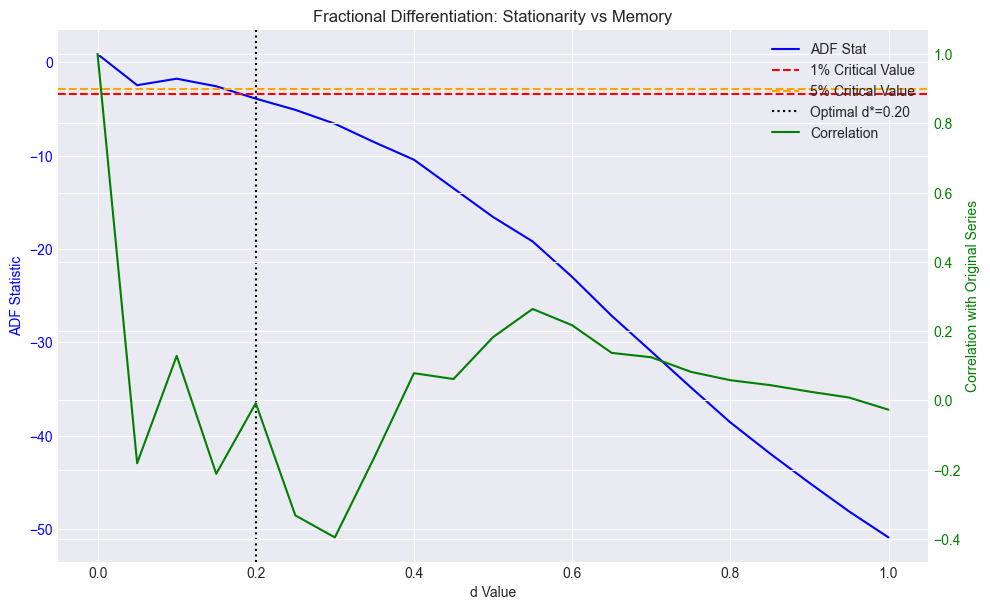

In [9]:
fig = plot_min_ffd(log_close)
plt.show()


## 7. Overlay Plot


c:\Users\maros\Downloads\AFML_Project\notebooks\..\src\fracdiff.py:46: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  series_np = series.fillna(method='ffill').dropna().values


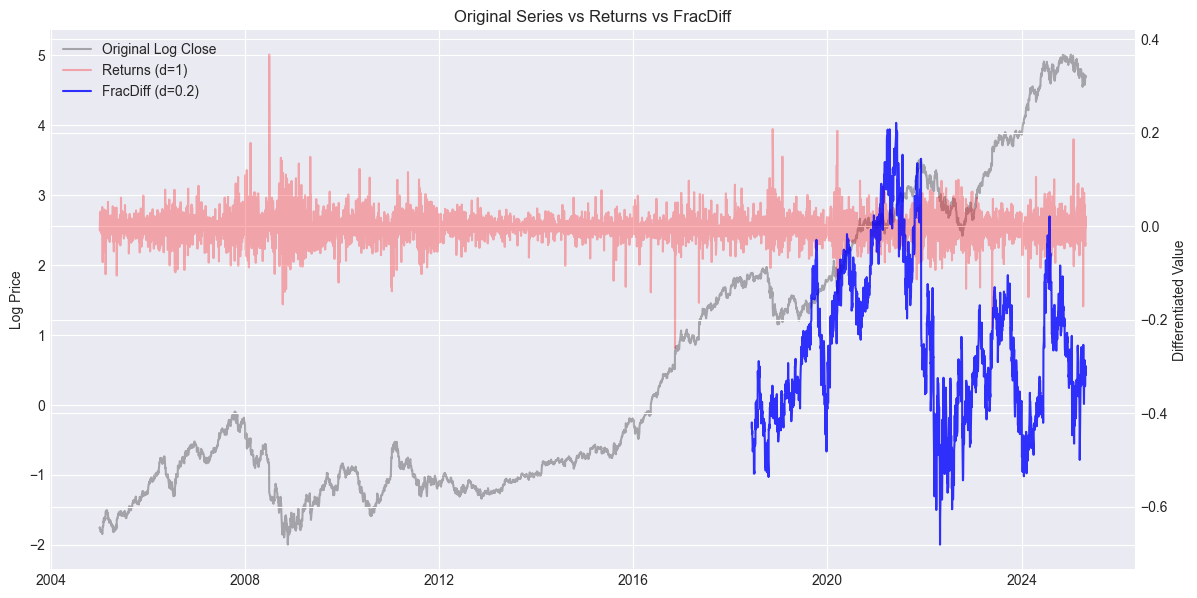

In [10]:
d_star_series = frac_diff_ffd(log_close, optimal_d, threshold=1e-5)
returns_series = frac_diff_ffd(log_close, 1.0, threshold=1e-5) # d=1 is approx first diff

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(log_close.index, log_close, label='Original Log Close', color='black', alpha=0.3)

ax2 = ax.twinx()
ax2.plot(returns_series.index, returns_series, label='Returns (d=1)', color='red', alpha=0.3)
ax2.plot(d_star_series.index, d_star_series, label=f'FracDiff (d={optimal_d})', color='blue', alpha=0.8)

ax.set_ylabel('Log Price')
ax2.set_ylabel('Differentiated Value')
ax.set_title('Original Series vs Returns vs FracDiff')

lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, loc='upper left')
plt.show()


## 8. Save Fractional Differentiation


In [11]:
frac_df = d_star_series.to_frame(name='fracdiff_d_star')
frac_df.to_parquet('../data/processed/nvda_fracdiff.parquet')
print("Saved nvda_fracdiff.parquet")


Saved nvda_fracdiff.parquet
